In [45]:
%matplotlib inline
import json, re
from datetime import datetime, timezone
import pandas as pd
import matplotlib.pyplot as plt

ARQUIVO = "fifa_jogos_completo.json"   # gerado pelo extrator com TODAS_AS_EDICOES=True
COR, COR2 = "#1f6feb", "#d1242f"
plt.rcParams["figure.figsize"] = (11, 5)

In [46]:
def texto(l, idioma="pt"):
    if not l: return ""
    if isinstance(l, str): return l
    for it in l:
        loc = (it.get("Locale") or "").lower()
        if loc == idioma or loc.startswith(idioma):
            return it.get("Description", "")
    return l[0].get("Description", "")

def num(x):
    try: return int(x)
    except (TypeError, ValueError): return None

def ano_edicao(j):
    m = re.search(r"(19|20)\d{2}", texto(j.get("SeasonName")))
    if m: return int(m.group())
    try: return int(str(j.get("Date") or "")[:4])
    except: return None

AGORA = datetime.now(timezone.utc).replace(tzinfo=None)
def disputado(j):
    iso = j.get("Date") or j.get("LocalDate")
    try: return datetime.strptime(str(iso)[:19], "%Y-%m-%dT%H:%M:%S") < AGORA
    except: return False

def padroniza_nome(nome):
    """Unifica selecoes que mudaram de nome.
    Alemanha + Alemanha Ocidental (RFA) viram uma so; a Oriental (RDA) fica separada."""
    if not nome: return nome
    n = nome.lower().strip()
    if "oriental" in n or "rda" in n or "east germany" in n:   # Alemanha Oriental: separada
        return nome
    if "aleman" in n or "germany" in n or "rfa" in n:          # Alemanha + Ocidental
        return "Alemanha"
    mapa = {  # sucessoras reconhecidas pela FIFA (opcional)
        "uniao sovietica": "Russia", "união soviética": "Russia", "urss": "Russia",
        "soviet union": "Russia",
        "iugoslavia": "Servia", "iugoslávia": "Servia", "yugoslavia": "Servia",
    }
    return mapa.get(n, nome)

with open(ARQUIVO, encoding="utf-8") as f:
    bruto = json.load(f)

linhas = []
for j in bruto:
    casa, fora = j.get("Home") or {}, j.get("Away") or {}
    gc = num(casa.get("Score"))
    if gc is None: gc = num(j.get("HomeTeamScore"))     # trata gol 0 corretamente
    gf = num(fora.get("Score"))
    if gf is None: gf = num(j.get("AwayTeamScore"))
    nc = padroniza_nome(texto(casa.get("TeamName")))
    nf = padroniza_nome(texto(fora.get("TeamName")))
    linhas.append({"ano": ano_edicao(j), "casa": nc, "fora": nf,
                   "gc": gc, "gf": gf, "disputado": disputado(j)})

df = pd.DataFrame(linhas)
df = df[df["disputado"] & df["gc"].notna() & df["gf"].notna() & df["ano"].notna()].copy()
df["gc"] = df["gc"].astype(int); df["gf"] = df["gf"].astype(int)
df["total"] = df["gc"] + df["gf"]

def vencedor(r):
    if r.gc > r.gf: return r.casa
    if r.gf > r.gc: return r.fora
    return "Empate"
df["vencedor"] = df.apply(vencedor, axis=1)

print(f"{len(df)} jogos carregados (de 1930 ate {int(df['ano'].max())})")
df.head()

1026 jogos carregados (de 1930 ate 2026)


,ano,casa,fora,gc,gf,disputado,total,vencedor
0,2026,México,África do Sul,2,0,True,2,México
1,2026,República da Coreia,Tchéquia,2,1,True,3,República da Coreia
2,2026,Canadá,Bósnia e Herzegovina,1,1,True,2,Empate
3,2026,EUA,Paraguai,4,1,True,5,EUA
4,2026,Catar,Suíça,1,1,True,2,Empate


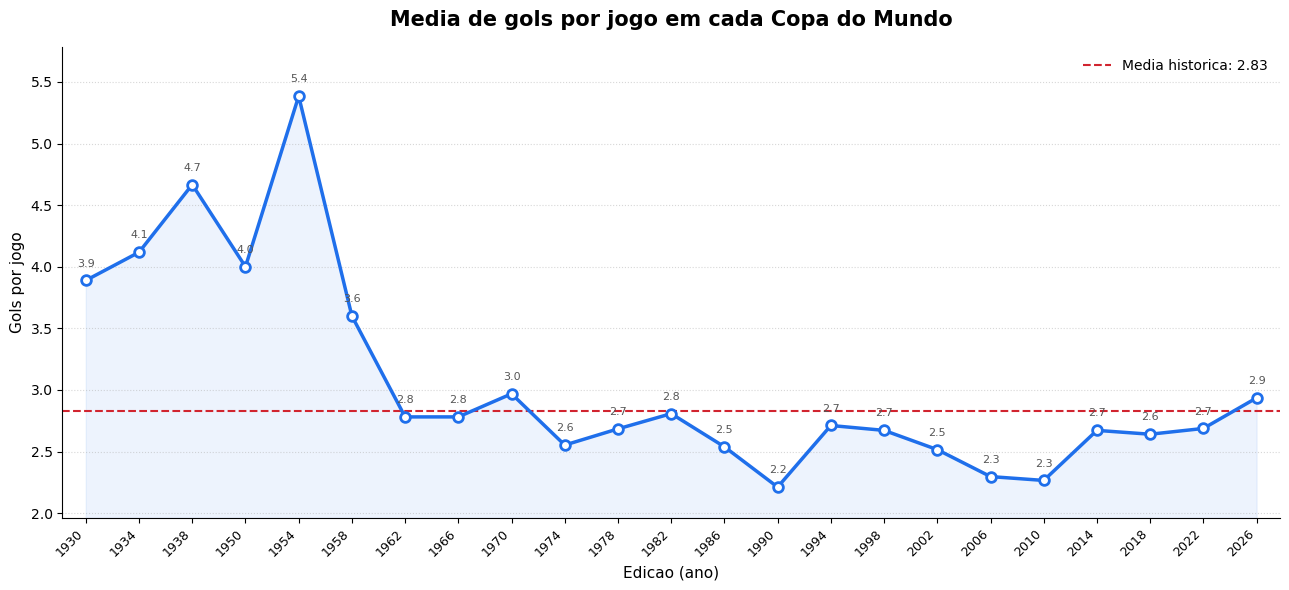

In [47]:
media = df.groupby("ano")["total"].mean().sort_index()
anos = [str(a) for a in media.index]
x = list(range(len(media)))
media_geral = df["total"].mean()
ymin = media.min() - 0.25

fig, ax = plt.subplots(figsize=(13, 6))
ax.fill_between(x, media.values, ymin, color=COR, alpha=0.08, zorder=1)
ax.plot(x, media.values, marker="o", markersize=7, linewidth=2.5, color=COR,
        markerfacecolor="white", markeredgecolor=COR, markeredgewidth=2, zorder=3)
ax.axhline(media_geral, color=COR2, ls="--", lw=1.5,
           label=f"Media historica: {media_geral:.2f}", zorder=2)

for xi, yi in zip(x, media.values):
    ax.annotate(f"{yi:.1f}", (xi, yi), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8, color="#555")

ax.set_xticks(x); ax.set_xticklabels(anos, rotation=45, ha="right", fontsize=9)
ax.set_ylim(ymin, media.max() + 0.4)
ax.set_title("Media de gols por jogo em cada Copa do Mundo",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Edicao (ano)", fontsize=11); ax.set_ylabel("Gols por jogo", fontsize=11)
ax.grid(axis="y", ls=":", alpha=0.5)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=10); ax.margins(x=0.02)
plt.tight_layout(); plt.show()

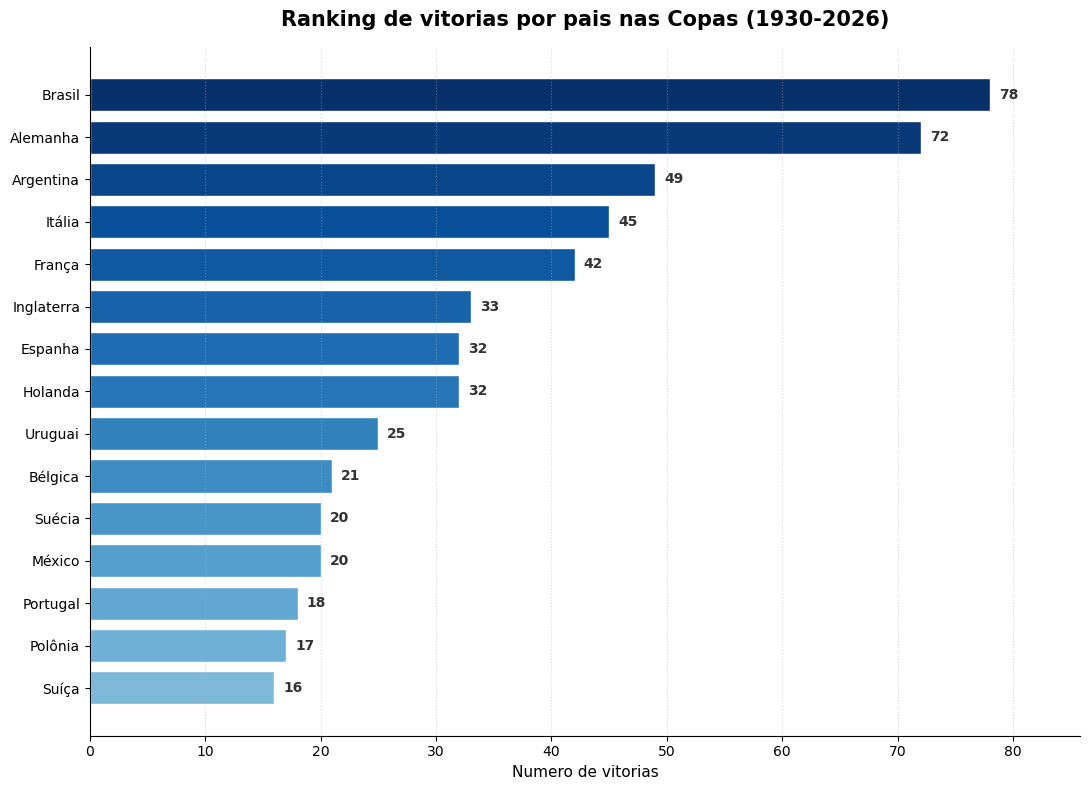

In [48]:
vit = df[df["vencedor"] != "Empate"]["vencedor"].value_counts().head(15)
top = vit.sort_values()
cores = plt.cm.Blues([0.45 + 0.55 * i / max(len(top) - 1, 1) for i in range(len(top))])

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top.index, top.values, color=cores, edgecolor="white", height=0.78)
for i, v in enumerate(top.values):
    ax.text(v + top.max() * 0.01, i, str(v), va="center",
            fontsize=10, color="#333", fontweight="bold")

ax.set_title("Ranking de vitorias por pais nas Copas (1930-2026)",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Numero de vitorias", fontsize=11)
ax.grid(axis="x", ls=":", alpha=0.5)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
ax.set_xlim(0, top.max() * 1.10)
plt.tight_layout(); plt.show()